  GROUND TRUTH FILE INVENTORY
           1000_ground_truth.npy  (25.8 MB)
            100_ground_truth.npy  (2.7 MB)
            250_ground_truth.npy  (6.6 MB)
            500_ground_truth.npy  (13.0 MB)

──────────────────────────────────────────────────────────────────────
  DEEP INSPECTION: 500_ground_truth.npy  (n_neurons = 500)
──────────────────────────────────────────────────────────────────────
  Type           : dict
  Total entries  : 1600

  Animals        : 8  -> ['501', '502', '503', '504', '505']...
  Sessions       : 5  -> ['1', '2', '3', '4', '5']
  Conditions     : 8  -> ['A_combined', 'A_rot', 'A_trans', 'B_combined', 'B_drift', 'B_dropout', 'B_rot', 'C_walk']
  Seeds          : 5  -> ['seed0', 'seed1', 'seed2', 'seed3', 'seed4']
  Expected files : 1600
  Actual files   : 1600

  -- Sample entry --
  Key   : '501_1__A_combined__seed0.npy'
  Fields: ['ground_truth_base_ids', 'permuted_roi_ids']
    ground_truth_base_ids          -> shape=(500,), dtype=int64, range=[0, 

C:\Users\ariAccount\AppData\Local\Temp\ipykernel_20952\1239593382.py:584: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Tier A saved -> C:\Users\ariAccount\Desktop\Ground_Truth_Sample\stars2cells_confusion_tier_A.png


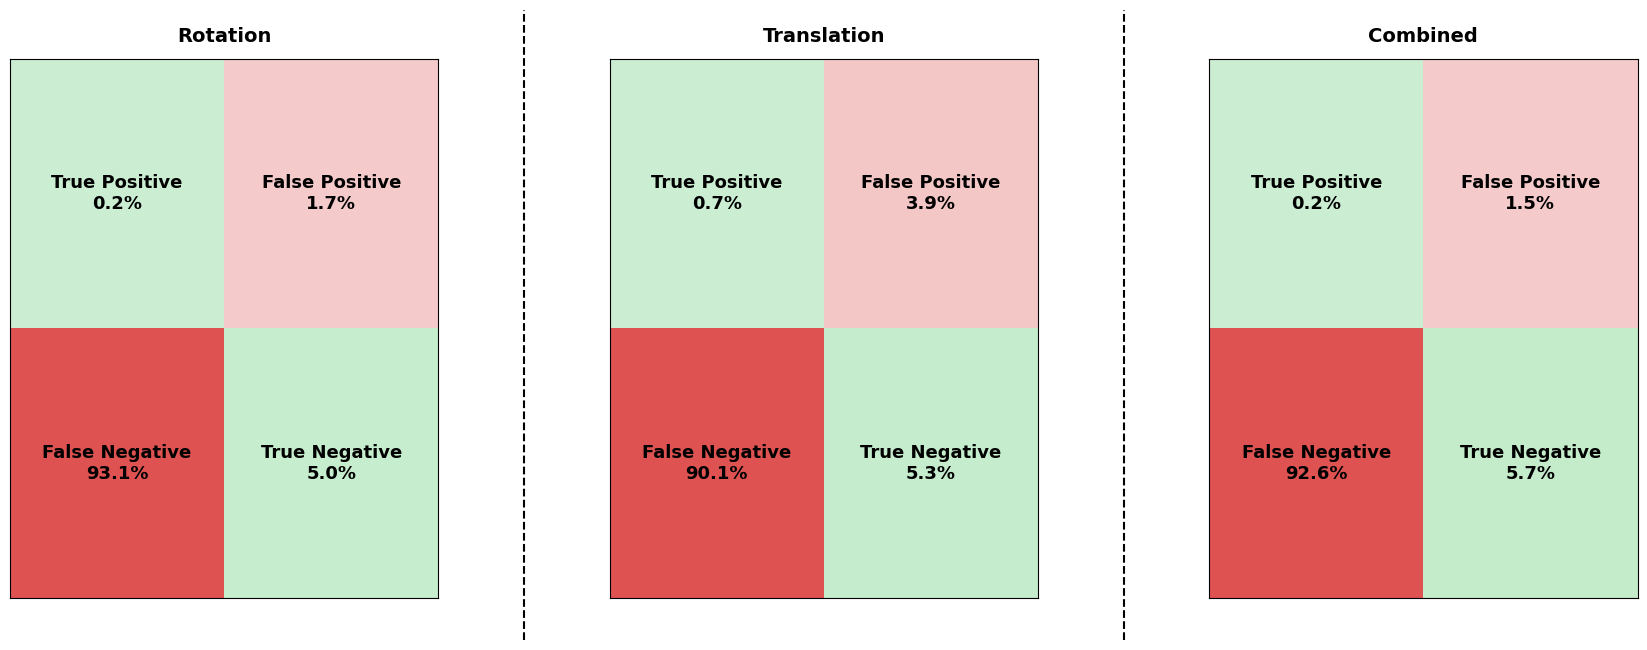

  Tier B saved -> C:\Users\ariAccount\Desktop\Ground_Truth_Sample\stars2cells_confusion_tier_B.png


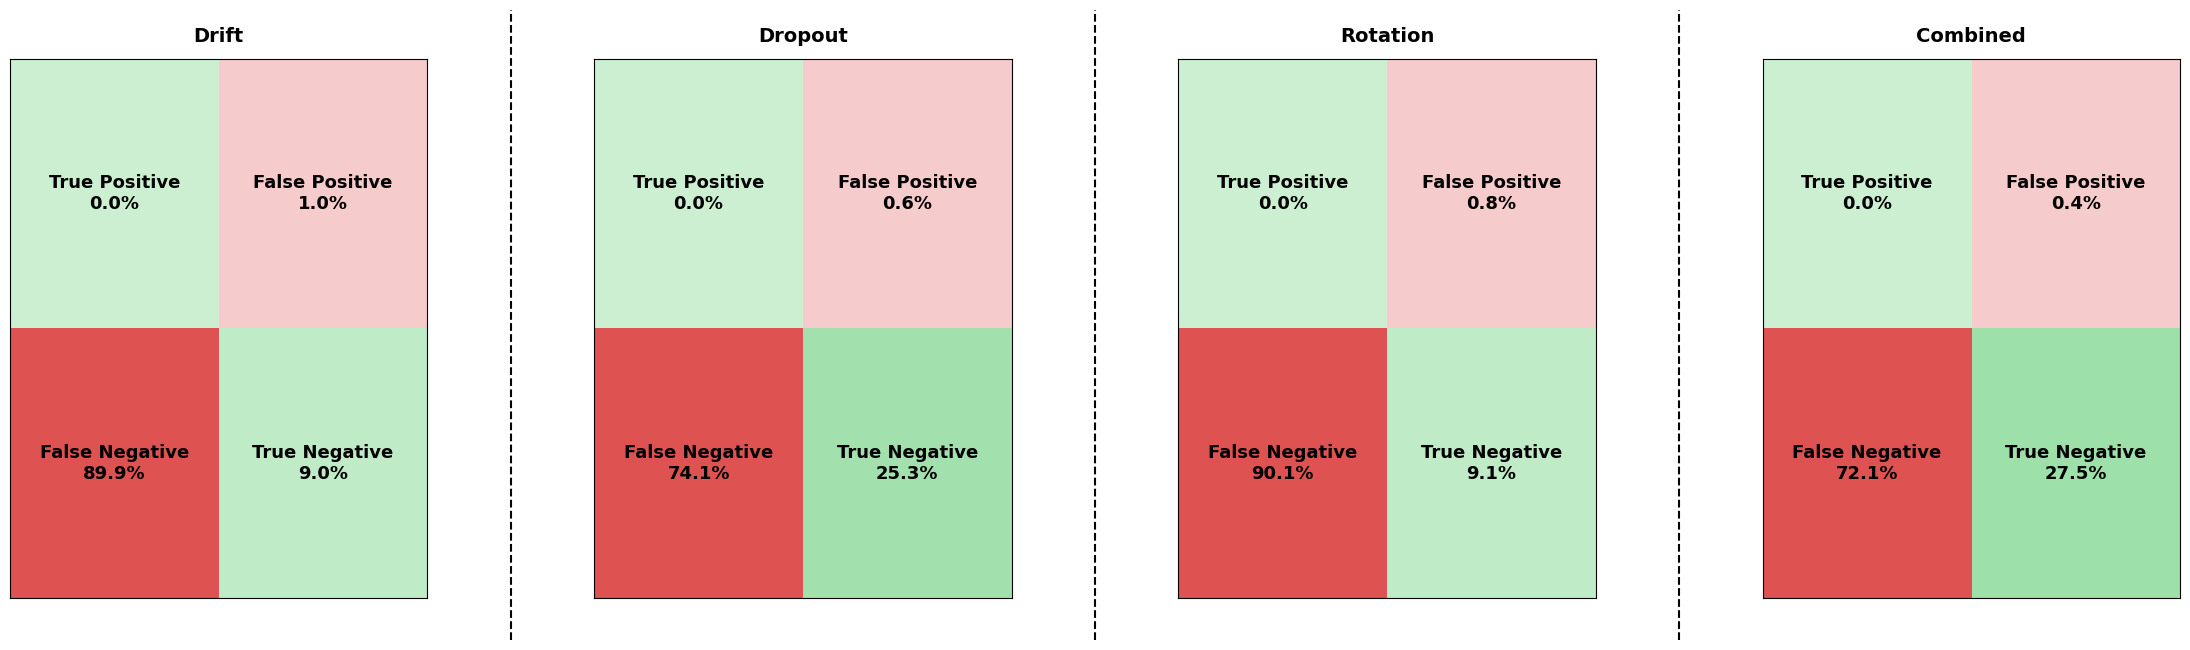

  Tier C saved -> C:\Users\ariAccount\Desktop\Ground_Truth_Sample\stars2cells_confusion_tier_C.png


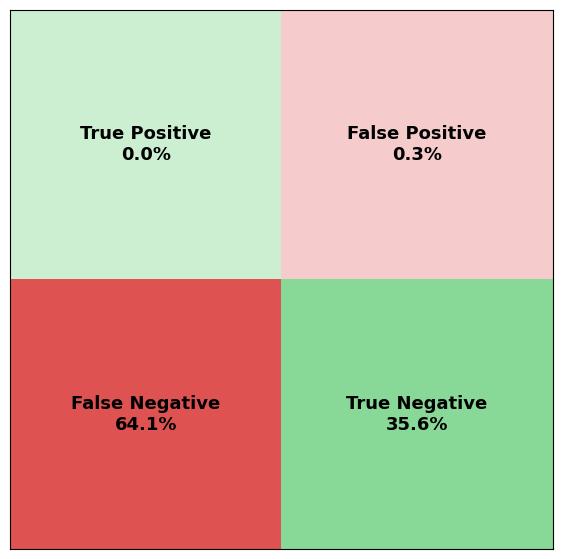


  ALL DONE
  ERROR BREAKDOWN
  Scored 1309 pairs

  Condition      Tier Pairs │     TP    FPa    FPu    FNa    FNu │   FPa%   FPu%   FNa%   FNu%
  ────────────── ──── ───── ┼ ────── ────── ────── ────── ────── ┼ ────── ────── ────── ──────
  A_rot             A   160 │    186   1444     87  77601     87 │   1.7%   0.1%  92.9%   0.1%
  A_trans           A   160 │    601   3329    212  76818    207 │   3.9%   0.2%  89.6%   0.2%
  A_combined        A   160 │    147   1271     81  77356     80 │   1.5%   0.1%  92.4%   0.1%
  B_drift           B   160 │     25    873     73  76047     71 │   1.0%   0.1%  89.8%   0.1%
  B_dropout         B   160 │     18    539    195  68060    180 │   0.6%   0.2%  73.8%   0.2%
  B_rot             B   160 │     13    708     58  76062     57 │   0.8%   0.1%  89.9%   0.1%
  B_combined        B   159 │      4    367    161  66568    152 │   0.4%   0.2%  71.9%   0.2%
  C_walk            C   158 │      3    302    186  61640    165 │   0.3%   0.2%  63.9%   0.2%

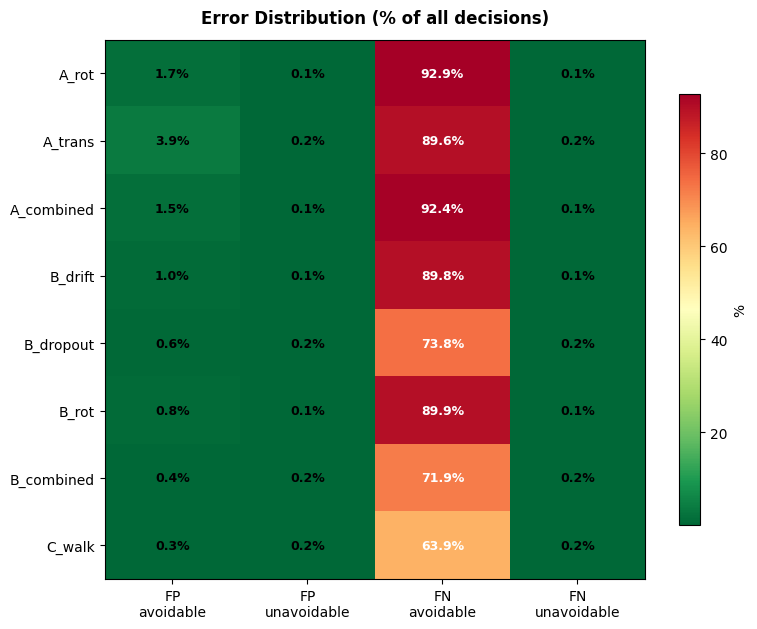

In [6]:
# %%
"""
Ground Truth Inspector & Verifier for Stars2Cells Benchmark  (v3)
==================================================================
1. Inspects ground_truth.npy structure
2. Verifies internal consistency
3. Loads Stars2Cells Step 3 results and scores match accuracy
4. Produces 2×2 confusion matrices (TP/FP/FN/TN) — one per tier

**v3 FIX**: S2C reorders centroids internally.  matched_ref_indices and
matched_tgt_indices index into S2C's *reordered* centroid arrays, NOT the
original .npy file ordering.  We now use a cKDTree spatial lookup to map
S2C indices → original file indices before scoring.

SCORING LOGIC
─────────────
Stars2Cells sees ALL centroids with no way to distinguish shared vs
dropped.  We separate ALL errors into avoidable vs unavoidable:

  TP:              correct match of shared neuron
  FP_avoidable:    both shared, wrong pairing (real mistake)
  FP_unavoidable:  at least one non-shared (can't avoid)
  FN_avoidable:    shared neuron missed, not caused by dropout
  FN_unavoidable:  shared neuron missed because dropout stole its slot
  TN:              non-shared neuron correctly ignored

The 2×2 uses only avoidable errors. Unavoidable counts annotated separately.

Usage:
    Update GT_DIR and RESULTS_DIR below, then run.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from scipy.spatial import cKDTree

# ═══════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════
GT_DIR      = Path(r"C:\Users\ariAccount\Desktop\Ground_Truth_Sample")
RESULTS_DIR = Path(r"C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_500n\step_3_results")
DATA_DIR    = Path(r"C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_500n")

N_NEURONS = 500

TIER_MAP = {
    'T0_identity': '0',
    'A_rot': 'A', 'A_trans': 'A', 'A_combined': 'A',
    'B_dropout': 'B', 'B_drift': 'B', 'B_rot': 'B', 'B_combined': 'B',
    'C_walk': 'C',
}

# Maximum distance (px) to accept a spatial match between S2C centroid
# and original file centroid.  Should be comfortably above jitter but
# well below inter-neuron spacing.
SPATIAL_MATCH_TOL = 5.0


# ═══════════════════════════════════════════════════════════════════════════
# SPATIAL REMAPPING HELPER
# ═══════════════════════════════════════════════════════════════════════════
def build_s2c_to_orig_map(s2c_centroids, orig_centroids, tol=SPATIAL_MATCH_TOL):
    """
    Map S2C's reordered centroid indices → original file indices.

    Parameters
    ----------
    s2c_centroids : (N, 2) array – centroids in S2C's internal order
    orig_centroids : (M, 2) array – centroids in original .npy file order
    tol : float – max distance (px) to accept a match

    Returns
    -------
    s2c_to_orig : dict  {s2c_idx: orig_idx}
        Only includes entries where the nearest neighbor is within tol.
    n_unmapped : int
        Number of S2C centroids that couldn't be mapped (should be 0).
    """
    tree = cKDTree(orig_centroids)
    dists, nearest = tree.query(s2c_centroids)

    s2c_to_orig = {}
    n_unmapped = 0
    for s2c_idx in range(len(s2c_centroids)):
        if dists[s2c_idx] <= tol:
            s2c_to_orig[s2c_idx] = int(nearest[s2c_idx])
        else:
            n_unmapped += 1

    return s2c_to_orig, n_unmapped


def load_orig_centroids(session_name, data_dir):
    """
    Load the original .npy file and return centroids as (N, 2) array.
    """
    fpath = data_dir / f"{session_name}.npy"
    if not fpath.exists():
        return None
    d = np.load(fpath, allow_pickle=True).item()
    x = d['centroids_x']
    y = d['centroids_y']
    return np.column_stack([x, y])


# ═══════════════════════════════════════════════════════════════════════════
# 1. LOAD & INSPECT GROUND TRUTH
# ═══════════════════════════════════════════════════════════════════════════
gt_files = sorted(GT_DIR.glob("*_ground_truth.npy"))
print("=" * 70)
print("  GROUND TRUTH FILE INVENTORY")
print("=" * 70)
for f in gt_files:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:>30s}  ({size_mb:.1f} MB)")

gt_path = GT_DIR / f"{N_NEURONS}_ground_truth.npy"
if not gt_path.exists():
    raise FileNotFoundError(f"Ground truth not found: {gt_path}")

gt = np.load(gt_path, allow_pickle=True).item()

print(f"\n{'─' * 70}")
print(f"  DEEP INSPECTION: {gt_path.name}  (n_neurons = {N_NEURONS})")
print(f"{'─' * 70}")
print(f"  Type           : {type(gt).__name__}")
print(f"  Total entries  : {len(gt)}")

animals, sessions, conditions, seeds = set(), set(), set(), set()
for k in gt.keys():
    parts = k.replace(".npy", "").split("__")
    animal_sess = parts[0].split("_")
    animals.add(animal_sess[0])
    sessions.add(animal_sess[1])
    conditions.add(parts[1])
    seeds.add(parts[2])

print(f"\n  Animals        : {len(animals)}  -> {sorted(animals)[:5]}...")
print(f"  Sessions       : {len(sessions)}  -> {sorted(sessions)}")
print(f"  Conditions     : {len(conditions)}  -> {sorted(conditions)}")
print(f"  Seeds          : {len(seeds)}  -> {sorted(seeds)}")
expected = len(animals) * len(sessions) * len(conditions) * len(seeds)
print(f"  Expected files : {expected}")
print(f"  Actual files   : {len(gt)}")

sample_key = sorted(gt.keys())[0]
sample_val = gt[sample_key]
print(f"\n  -- Sample entry --")
print(f"  Key   : '{sample_key}'")
print(f"  Fields: {list(sample_val.keys())}")
for field_name, arr in sample_val.items():
    print(f"    {field_name:30s} -> shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.0f}, {arr.max():.0f}]")


# ═══════════════════════════════════════════════════════════════════════════
# 2. VERIFY GROUND TRUTH INTERNAL CONSISTENCY
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print("  VERIFICATION CHECKS")
print("=" * 70)

n_checked, n_passed = 0, 0
issues = []

for fname, entry in gt.items():
    gt_ids   = entry['ground_truth_base_ids']
    perm_ids = entry['permuted_roi_ids']
    if len(gt_ids) != len(perm_ids):
        issues.append(f"  LENGTH MISMATCH: {fname}")
        continue
    if sorted(gt_ids) != sorted(perm_ids):
        issues.append(f"  MULTISET MISMATCH: {fname}")
        continue
    n_checked += 1
    n_passed  += 1

status = "PASS" if not issues else "FAIL"
print(f"\n  Entries checked : {n_checked}")
print(f"  Entries passed  : {n_passed}")
print(f"  Issues found    : {len(issues)}")
print(f"  Overall status  : {status}")
for iss in issues[:10]:
    print(f"    {iss}")

print(f"\n{'─' * 70}")
print("  NEURON COUNT STATS PER CONDITION")
print(f"{'─' * 70}")
cond_counts = defaultdict(list)
for fname, entry in gt.items():
    cond = fname.replace(".npy", "").split("__")[1]
    cond_counts[cond].append(len(entry['ground_truth_base_ids']))

for cond in sorted(cond_counts.keys()):
    c = cond_counts[cond]
    print(f"  {cond:15s} -- mean={np.mean(c):.1f}, min={np.min(c)}, "
          f"max={np.max(c)}, std={np.std(c):.1f}")


# ═══════════════════════════════════════════════════════════════════════════
# HELPER: Score a single pair
# ═══════════════════════════════════════════════════════════════════════════
def score_pair(matched_ref_orig, matched_tgt_orig, ref_base_ids, tgt_base_ids):
    """
    Score with full avoidable/unavoidable split for both FP and FN.

    IMPORTANT: matched_ref_orig and matched_tgt_orig must already be
    remapped to ORIGINAL file indices (not S2C internal indices).
    """
    ref_id_set = set(ref_base_ids)
    tgt_id_set = set(tgt_base_ids)
    shared_ids = ref_id_set & tgt_id_set
    n_shared = len(shared_ids)
    n_ref = len(ref_base_ids)
    n_tgt = len(tgt_base_ids)

    matched_ref_set = set(int(x) for x in matched_ref_orig)
    matched_tgt_set = set(int(x) for x in matched_tgt_orig)

    tp = 0
    fp_avoidable = 0
    fp_unavoidable = 0
    correctly_matched_ids = set()

    ref_idx_match_info = {}
    tgt_idx_match_info = {}

    for ri, ti in zip(matched_ref_orig, matched_tgt_orig):
        ri, ti = int(ri), int(ti)
        if ri < n_ref and ti < n_tgt:
            r_id = ref_base_ids[ri]
            t_id = tgt_base_ids[ti]
            r_shared = r_id in shared_ids
            t_shared = t_id in shared_ids

            info = {'r_shared': r_shared, 't_shared': t_shared}
            ref_idx_match_info[ri] = info
            tgt_idx_match_info[ti] = info

            if r_id == t_id and r_shared:
                tp += 1
                correctly_matched_ids.add(r_id)
            elif r_shared and t_shared:
                fp_avoidable += 1
            else:
                fp_unavoidable += 1
        else:
            fp_unavoidable += 1

    missed_ids = shared_ids - correctly_matched_ids
    fn_avoidable = 0
    fn_unavoidable = 0

    for miss_id in missed_ids:
        ref_positions = np.where(ref_base_ids == miss_id)[0]
        tgt_positions = np.where(tgt_base_ids == miss_id)[0]

        consumed_by_nonshared = False
        for rp in ref_positions:
            rp = int(rp)
            if rp in ref_idx_match_info and not ref_idx_match_info[rp]['t_shared']:
                consumed_by_nonshared = True
                break
        if not consumed_by_nonshared:
            for tp_idx in tgt_positions:
                tp_idx = int(tp_idx)
                if tp_idx in tgt_idx_match_info and not tgt_idx_match_info[tp_idx]['r_shared']:
                    consumed_by_nonshared = True
                    break

        if consumed_by_nonshared:
            fn_unavoidable += 1
        else:
            fn_avoidable += 1

    nonshared_ref = {i for i, bid in enumerate(ref_base_ids) if bid not in shared_ids}
    nonshared_tgt = {i for i, bid in enumerate(tgt_base_ids) if bid not in shared_ids}
    nonshared_in_match = set()
    for ri in (nonshared_ref & matched_ref_set):
        nonshared_in_match.add(('ref', ref_base_ids[ri]))
    for ti in (nonshared_tgt & matched_tgt_set):
        nonshared_in_match.add(('tgt', tgt_base_ids[ti]))
    n_nonshared = len(nonshared_ref) + len(nonshared_tgt)
    tn = n_nonshared - len(nonshared_in_match)

    n_matches = len(matched_ref_orig)
    fp_all = fp_avoidable + fp_unavoidable
    fn_all = fn_avoidable + fn_unavoidable

    def _safe_div(a, b):
        return a / b if b > 0 else float('nan')

    def _f1(p, r):
        if np.isnan(p) or np.isnan(r) or (p + r) == 0:
            return float('nan')
        return 2 * p * r / (p + r)

    prec_raw = _safe_div(tp, tp + fp_all)
    prec_adj = _safe_div(tp, tp + fp_avoidable)
    recall_raw = _safe_div(tp, tp + fn_all)
    recall_adj = _safe_div(tp, tp + fn_avoidable)

    return {
        'tp': tp,
        'fp_avoidable': fp_avoidable, 'fp_unavoidable': fp_unavoidable,
        'fn_avoidable': fn_avoidable, 'fn_unavoidable': fn_unavoidable,
        'tn': tn,
        'n_shared': n_shared, 'n_nonshared': n_nonshared,
        'n_ref': n_ref, 'n_tgt': n_tgt, 'n_matches': n_matches,
        'prec_raw': prec_raw, 'prec_adj': prec_adj,
        'recall_raw': recall_raw, 'recall_adj': recall_adj,
        'f1_raw': _f1(prec_raw, recall_raw), 'f1_adj': _f1(prec_adj, recall_adj),
    }


# ═══════════════════════════════════════════════════════════════════════════
# 3. LOAD STARS2CELLS RESULTS & SCORE  (with spatial remapping)
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print("  SCORING STARS2CELLS RESULTS AGAINST GROUND TRUTH")
print("  (v3: spatial remapping via cKDTree)")
print("=" * 70)

step3_dir = None
for candidate in [RESULTS_DIR / "step_3_results", RESULTS_DIR / "step_3", RESULTS_DIR]:
    if candidate.exists() and list(candidate.glob("*_sweep.npz")):
        step3_dir = candidate
        break

sweep_files = sorted(step3_dir.glob("*_sweep.npz")) if step3_dir else []
print(f"  Results dir    : {step3_dir}")
print(f"  Data dir       : {DATA_DIR}")
print(f"  Sweep files    : {len(sweep_files)}")
print(f"  Spatial tol    : {SPATIAL_MATCH_TOL} px")

pair_scores = []
key_errors  = 0
remap_warnings = 0

_empty = {
    'tp': 0, 'fp_avoidable': 0, 'fp_unavoidable': 0,
    'fn_avoidable': 0, 'fn_unavoidable': 0, 'tn': 0,
    'n_matches': 0, 'n_shared': 0, 'n_nonshared': 0,
    'n_ref': 0, 'n_tgt': 0,
    'prec_raw': float('nan'), 'prec_adj': float('nan'),
    'recall_raw': float('nan'), 'recall_adj': float('nan'),
    'f1_raw': float('nan'), 'f1_adj': float('nan'),
}

for sweep_file in sweep_files:
    data = np.load(sweep_file, allow_pickle=False)

    animal_id   = str(data['animal_id'])
    pair_name   = str(data['pair_name'])
    ref_session = str(data['ref_session'])
    tgt_session = str(data['target_session'])
    matched_ref_s2c = data['matched_ref_indices']   # in S2C's order
    matched_tgt_s2c = data['matched_tgt_indices']   # in S2C's order
    s2c_ref_centroids = data['ref_centroids']       # (N, 2) S2C order
    s2c_tgt_centroids = data['tgt_centroids']       # (M, 2) S2C order
    n_matches   = len(matched_ref_s2c)

    parts = ref_session.split("__")
    cond_found = parts[1] if len(parts) >= 2 else "?"
    seed_found = parts[2] if len(parts) >= 3 else "?"
    tier_found = TIER_MAP.get(cond_found, "?")

    base_info = {
        'pair_name': pair_name, 'animal_id': animal_id,
        'ref_session': ref_session, 'tgt_session': tgt_session,
        'condition': cond_found, 'seed': seed_found, 'tier': tier_found,
    }

    ref_gt_key = f"{ref_session}.npy"
    tgt_gt_key = f"{tgt_session}.npy"

    if n_matches == 0 or ref_gt_key not in gt or tgt_gt_key not in gt:
        if ref_gt_key not in gt or tgt_gt_key not in gt:
            key_errors += 1
            print(f"  WARN: GT key not found for {pair_name}")
        pair_scores.append({**base_info, **_empty, 'n_matches': n_matches})
        continue

    # ── Load original file centroids ──
    orig_ref = load_orig_centroids(ref_session, DATA_DIR)
    orig_tgt = load_orig_centroids(tgt_session, DATA_DIR)

    if orig_ref is None or orig_tgt is None:
        key_errors += 1
        print(f"  WARN: Original .npy not found for {pair_name}")
        pair_scores.append({**base_info, **_empty, 'n_matches': n_matches})
        continue

    # ── Build spatial remapping: S2C index → original file index ──
    ref_map, ref_unmapped = build_s2c_to_orig_map(s2c_ref_centroids, orig_ref)
    tgt_map, tgt_unmapped = build_s2c_to_orig_map(s2c_tgt_centroids, orig_tgt)

    if ref_unmapped > 0 or tgt_unmapped > 0:
        remap_warnings += 1
        if remap_warnings <= 5:
            print(f"  WARN: Unmapped centroids in {pair_name}: "
                  f"ref={ref_unmapped}, tgt={tgt_unmapped}")

    # ── Remap matched indices from S2C space → original file space ──
    matched_ref_orig = []
    matched_tgt_orig = []
    skipped = 0
    for ri_s2c, ti_s2c in zip(matched_ref_s2c, matched_tgt_s2c):
        ri_s2c, ti_s2c = int(ri_s2c), int(ti_s2c)
        if ri_s2c in ref_map and ti_s2c in tgt_map:
            matched_ref_orig.append(ref_map[ri_s2c])
            matched_tgt_orig.append(tgt_map[ti_s2c])
        else:
            skipped += 1

    matched_ref_orig = np.array(matched_ref_orig, dtype=int)
    matched_tgt_orig = np.array(matched_tgt_orig, dtype=int)

    ref_base_ids = gt[ref_gt_key]['ground_truth_base_ids']
    tgt_base_ids = gt[tgt_gt_key]['ground_truth_base_ids']
    result = score_pair(matched_ref_orig, matched_tgt_orig, ref_base_ids, tgt_base_ids)
    pair_scores.append({**base_info, **result})


# ── Print summary table ──
print(f"\n  Scored {len(pair_scores)} session pairs  "
      f"(key errors: {key_errors}, remap warnings: {remap_warnings})\n")
if pair_scores:
    print(f"  {'Pair':<52} {'Cond':<12} {'Shrd':>4} {'TP':>4} {'FPa':>4} "
          f"{'FPu':>4} {'FNa':>4} {'FNu':>4} {'TN':>4} {'Pa':>6} {'Ra':>6} {'F1a':>6}")
    print(f"  {'─' * 135}")
    for ps in sorted(pair_scores, key=lambda x: (x['tier'], x['condition'], x['pair_name'])):
        pa_s = f"{ps['prec_adj']*100:.0f}%" if not np.isnan(ps['prec_adj']) else "N/A"
        ra_s = f"{ps['recall_adj']*100:.0f}%" if not np.isnan(ps['recall_adj']) else "N/A"
        f1_s = f"{ps['f1_adj']*100:.0f}%" if not np.isnan(ps['f1_adj']) else "N/A"
        print(f"  {ps['pair_name']:<52} {ps['condition']:<12} "
              f"{ps['n_shared']:>4} {ps['tp']:>4} {ps['fp_avoidable']:>4} "
              f"{ps['fp_unavoidable']:>4} {ps['fn_avoidable']:>4} {ps['fn_unavoidable']:>4} "
              f"{ps['tn']:>4} {pa_s:>6} {ra_s:>6} {f1_s:>6}")

    # ── Per-condition summary ──
    print(f"\n  {'─' * 100}")
    print(f"  SUMMARY BY CONDITION:")
    print(f"  {'─' * 100}")
    print(f"  {'Condition':<15} {'Tier':>4} {'n':>5} "
          f"{'P_raw':>7} {'P_adj':>7} {'R_raw':>7} {'R_adj':>7} "
          f"{'F1_raw':>7} {'F1_adj':>7}")
    print(f"  {'─' * 100}")

    cond_m = defaultdict(lambda: {'pr': [], 'pa': [], 'rr': [], 'ra': [], 'f1r': [], 'f1a': []})
    for ps in pair_scores:
        c = ps['condition']
        for k_from, k_to in [('prec_raw','pr'), ('prec_adj','pa'),
                              ('recall_raw','rr'), ('recall_adj','ra'),
                              ('f1_raw','f1r'), ('f1_adj','f1a')]:
            if not np.isnan(ps[k_from]):
                cond_m[c][k_to].append(ps[k_from])

    for cond in sorted(cond_m.keys()):
        m = cond_m[cond]
        tier = TIER_MAP.get(cond, '?')
        n = len(m['ra'])
        print(f"  {cond:<15} {tier:>4} {n:>5} "
              f"{np.mean(m['pr'])*100:>6.1f}% {np.mean(m['pa'])*100:>6.1f}% "
              f"{np.mean(m['rr'])*100:>6.1f}% {np.mean(m['ra'])*100:>6.1f}% "
              f"{np.mean(m['f1r'])*100:>6.1f}% {np.mean(m['f1a'])*100:>6.1f}%")

    def _safe_mean(key):
        vals = [ps[key] for ps in pair_scores if not np.isnan(ps[key])]
        return np.mean(vals) * 100 if vals else float('nan')

    print(f"\n  OVERALL:")
    print(f"    Precision (raw / adj):  {_safe_mean('prec_raw'):.1f}% / {_safe_mean('prec_adj'):.1f}%")
    print(f"    Recall    (raw / adj):  {_safe_mean('recall_raw'):.1f}% / {_safe_mean('recall_adj'):.1f}%")
    print(f"    F1        (raw / adj):  {_safe_mean('f1_raw'):.1f}% / {_safe_mean('f1_adj'):.1f}%")


# ═══════════════════════════════════════════════════════════════════════════
# 4. 2×2 CONFUSION MATRICES — One per Tier (avoidable errors only)
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print("  GENERATING 2x2 CONFUSION MATRICES (one per tier)")
print("=" * 70)

COND_DISPLAY = {
    'T0_identity': 'Identity',
    'A_rot': 'Rotation', 'A_trans': 'Translation', 'A_combined': 'Combined',
    'B_rot': 'Rotation', 'B_drift': 'Drift', 'B_dropout': 'Dropout',
    'B_combined': 'Combined',
    'C_walk': None,
}

if pair_scores:
    for tier_label in ['0', 'A', 'B', 'C']:
        tier_pairs = [ps for ps in pair_scores
                      if ps['tier'] == tier_label
                      and not np.isnan(ps['recall_adj'])]
        if not tier_pairs:
            print(f"  Tier {tier_label}: no scored pairs, skipping.")
            continue

        cond_totals = defaultdict(lambda: {
            'tp': 0, 'fp_a': 0, 'fp_u': 0, 'fn_a': 0, 'fn_u': 0, 'tn': 0,
        })
        for ps in tier_pairs:
            c = ps['condition']
            cond_totals[c]['tp']   += ps['tp']
            cond_totals[c]['fp_a'] += ps['fp_avoidable']
            cond_totals[c]['fp_u'] += ps['fp_unavoidable']
            cond_totals[c]['fn_a'] += ps['fn_avoidable']
            cond_totals[c]['fn_u'] += ps['fn_unavoidable']
            cond_totals[c]['tn']   += ps['tn']

        cond_names = sorted(cond_totals.keys(),
                            key=lambda c: (1 if 'combined' in c.lower() else 0, c))
        n_conds = len(cond_names)

        fig, axes = plt.subplots(1, n_conds,
                                  figsize=(7 * n_conds, 7),
                                  gridspec_kw={'wspace': 0.4})
        if n_conds == 1:
            axes = [axes]

        for col, cname in enumerate(cond_names):
            ax = axes[col]
            t = cond_totals[cname]

            mat = np.array([
                [t['tp'],   t['fp_a']],
                [t['fn_a'], t['tn']],
            ], dtype=float)

            total = mat.sum()
            mat_pct = mat / total * 100 if total > 0 else mat * 0

            colors = np.zeros((2, 2, 4))
            color_map = {
                (0, 0): [0.2, 0.75, 0.3],   # TP - green
                (0, 1): [0.85, 0.2, 0.2],    # FP - red
                (1, 0): [0.85, 0.2, 0.2],    # FN - red
                (1, 1): [0.2, 0.75, 0.3],    # TN - green
            }
            max_pct = mat_pct.max() if mat_pct.max() > 0 else 1
            for r in range(2):
                for c_idx in range(2):
                    colors[r, c_idx, :3] = color_map[(r, c_idx)]
                    colors[r, c_idx, 3] = 0.25 + 0.6 * (mat_pct[r, c_idx] / max_pct)

            ax.imshow(colors, aspect='auto', interpolation='none')

            labels_2x2 = [['True Positive', 'False Positive'],
                          ['False Negative', 'True Negative']]
            for r in range(2):
                for c_idx in range(2):
                    pct = mat_pct[r, c_idx]
                    ax.text(c_idx, r,
                            f"{labels_2x2[r][c_idx]}\n{pct:.1f}%",
                            ha='center', va='center',
                            fontsize=13, fontweight='bold', color='black')

            ax.set_xticks([])
            ax.set_yticks([])

            display_name = COND_DISPLAY.get(cname, cname)
            if display_name:
                ax.set_title(display_name, fontsize=14, fontweight='bold', pad=12)

        # Vertical separators
        if n_conds > 1:
            for col in range(n_conds - 1):
                bbox_right = axes[col].get_position()
                bbox_left  = axes[col + 1].get_position()
                mid_x = (bbox_right.x1 + bbox_left.x0) / 2
                fig.add_artist(plt.Line2D(
                    [mid_x, mid_x], [0.05, 0.95],
                    transform=fig.transFigure,
                    color='black', linestyle='--', linewidth=1.5,
                ))

        tier_display = '0 (Identity)' if tier_label == '0' else tier_label
        save_path = GT_DIR / f"stars2cells_confusion_tier_{tier_label}.png"
        fig.tight_layout()
        if n_conds > 1:
            fig.artists.clear()
            for col in range(n_conds - 1):
                bbox_right = axes[col].get_position()
                bbox_left  = axes[col + 1].get_position()
                mid_x = (bbox_right.x1 + bbox_left.x0) / 2
                fig.add_artist(plt.Line2D(
                    [mid_x, mid_x], [0.05, 0.95],
                    transform=fig.transFigure,
                    color='black', linestyle='--', linewidth=1.5,
                ))
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Tier {tier_display} saved -> {save_path}")
        plt.show()


print(f"\n{'=' * 70}")
print("  ALL DONE")
print("=" * 70)

# %%
# ═══════════════════════════════════════════════════════════════════════════
# ERROR DIAGNOSIS HEATMAP
# ═══════════════════════════════════════════════════════════════════════════
#
# Recreates the error breakdown table + heatmap from scored pair results.
#
# Assumes in scope: pair_scores, gt, score_pair, TIER_MAP, GT_DIR,
#                   RESULTS_DIR, N_NEURONS
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

print("=" * 90)
print("  ERROR BREAKDOWN")
print("=" * 90)
print(f"  Scored {len(pair_scores)} pairs\n")

# ── Aggregate by condition ────────────────────────────────────────────
cond_agg = defaultdict(lambda: {
    'n': 0, 'tp': 0, 'fp_a': 0, 'fp_u': 0, 'fn_a': 0, 'fn_u': 0, 'tn': 0,
})

for ps in pair_scores:
    if np.isnan(ps.get('recall_adj', float('nan'))):
        continue
    c = ps['condition']
    cond_agg[c]['n'] += 1
    cond_agg[c]['tp']   += ps['tp']
    cond_agg[c]['fp_a'] += ps['fp_avoidable']
    cond_agg[c]['fp_u'] += ps['fp_unavoidable']
    cond_agg[c]['fn_a'] += ps['fn_avoidable']
    cond_agg[c]['fn_u'] += ps['fn_unavoidable']
    cond_agg[c]['tn']   += ps['tn']

cond_order = sorted(cond_agg.keys(),
                    key=lambda c: (
                        {'0': 0, 'A': 1, 'B': 2, 'C': 3}.get(TIER_MAP.get(c, 'Z'), 9),
                        1 if 'combined' in c.lower() else 0,
                        c,
                    ))

# ── Table ─────────────────────────────────────────────────────────────
print(f"  {'Condition':<14} {'Tier':>4} {'Pairs':>5} │ "
      f"{'TP':>6} {'FPa':>6} {'FPu':>6} {'FNa':>6} {'FNu':>6} │ "
      f"{'FPa%':>6} {'FPu%':>6} {'FNa%':>6} {'FNu%':>6}")
print(f"  {'─'*14} {'─'*4} {'─'*5} ┼ {'─'*6} {'─'*6} {'─'*6} {'─'*6} {'─'*6} ┼ {'─'*6} {'─'*6} {'─'*6} {'─'*6}")

for c in cond_order:
    a = cond_agg[c]
    tier = TIER_MAP.get(c, '?')
    total = a['tp'] + a['fp_a'] + a['fp_u'] + a['fn_a'] + a['fn_u'] + a['tn']
    if total == 0:
        continue
    print(f"  {c:<14} {tier:>4} {a['n']:>5} │ "
          f"{a['tp']:>6} {a['fp_a']:>6} {a['fp_u']:>6} {a['fn_a']:>6} {a['fn_u']:>6} │ "
          f"{a['fp_a']/total*100:>5.1f}% {a['fp_u']/total*100:>5.1f}% "
          f"{a['fn_a']/total*100:>5.1f}% {a['fn_u']/total*100:>5.1f}%")

# ── Heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(4, len(cond_order) * 0.8)))

labels_col = ['FP\navoidable', 'FP\nunavoidable', 'FN\navoidable', 'FN\nunavoidable']
keys =       ['fp_a',          'fp_u',             'fn_a',          'fn_u']

mat = np.zeros((len(cond_order), len(labels_col)))
for i, c in enumerate(cond_order):
    a = cond_agg[c]
    total = a['tp'] + a['fp_a'] + a['fp_u'] + a['fn_a'] + a['fn_u'] + a['tn']
    if total > 0:
        for j, k in enumerate(keys):
            mat[i, j] = a[k] / total * 100

im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r')
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        color = 'white' if val > 40 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

ax.set_xticks(range(len(labels_col)))
ax.set_xticklabels(labels_col, fontsize=10)
ax.set_yticks(range(len(cond_order)))
ax.set_yticklabels(cond_order, fontsize=10)
ax.set_title('Error Distribution (% of all decisions)',
             fontsize=12, fontweight='bold', pad=12)
fig.colorbar(im, ax=ax, label='%', shrink=0.8)
fig.tight_layout()
plt.show()


██████████████████████████████████████████████████████████████████████
  STARS2CELLS BENCHMARK — 250 neurons
██████████████████████████████████████████████████████████████████████
  Data dir    : C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_250n
  Results dir : C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_250n\step_3_results
  GT entries  : 1640
  Conditions  : ['A_combined', 'A_rot', 'A_trans', 'B_combined', 'B_drift', 'B_dropout', 'B_rot', 'C_walk', 'T0_identity']

  Neuron counts per condition:
    A_combined      -- mean=239.9, min=222, max=250
    A_rot           -- mean=240.7, min=222, max=250
    A_trans         -- mean=244.0, min=233, max=250
    B_combined      -- mean=198.9, min=139, max=250
    B_drift         -- mean=228.0, min=190, max=250
    B_dropout       -- mean=209.1, min=165, max=250
    B_rot           -- mean=224.0, min=190, max=250
    C_walk          -- mean=197.4, min=143, max=250
    T0_identity     -- mean=250.0, min=250, max=250

  Sweep files : 1

C:\Users\ariAccount\AppData\Local\Temp\ipykernel_20952\2465462316.py:364: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


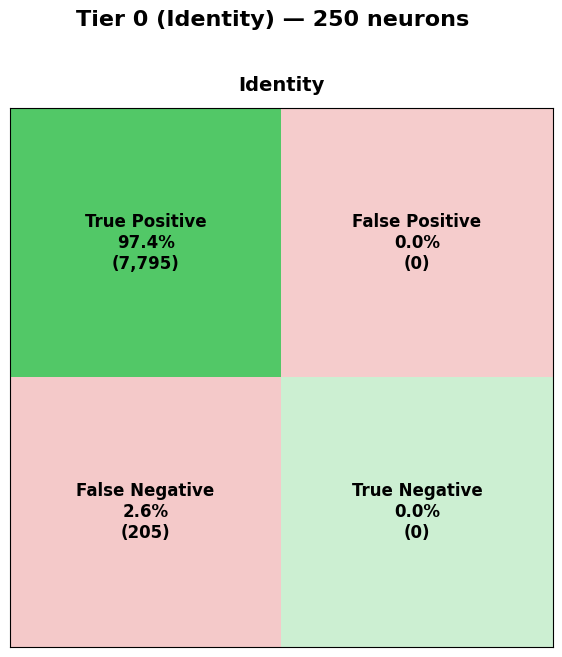

  Tier A -> C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_250n\confusion_tier_A.png


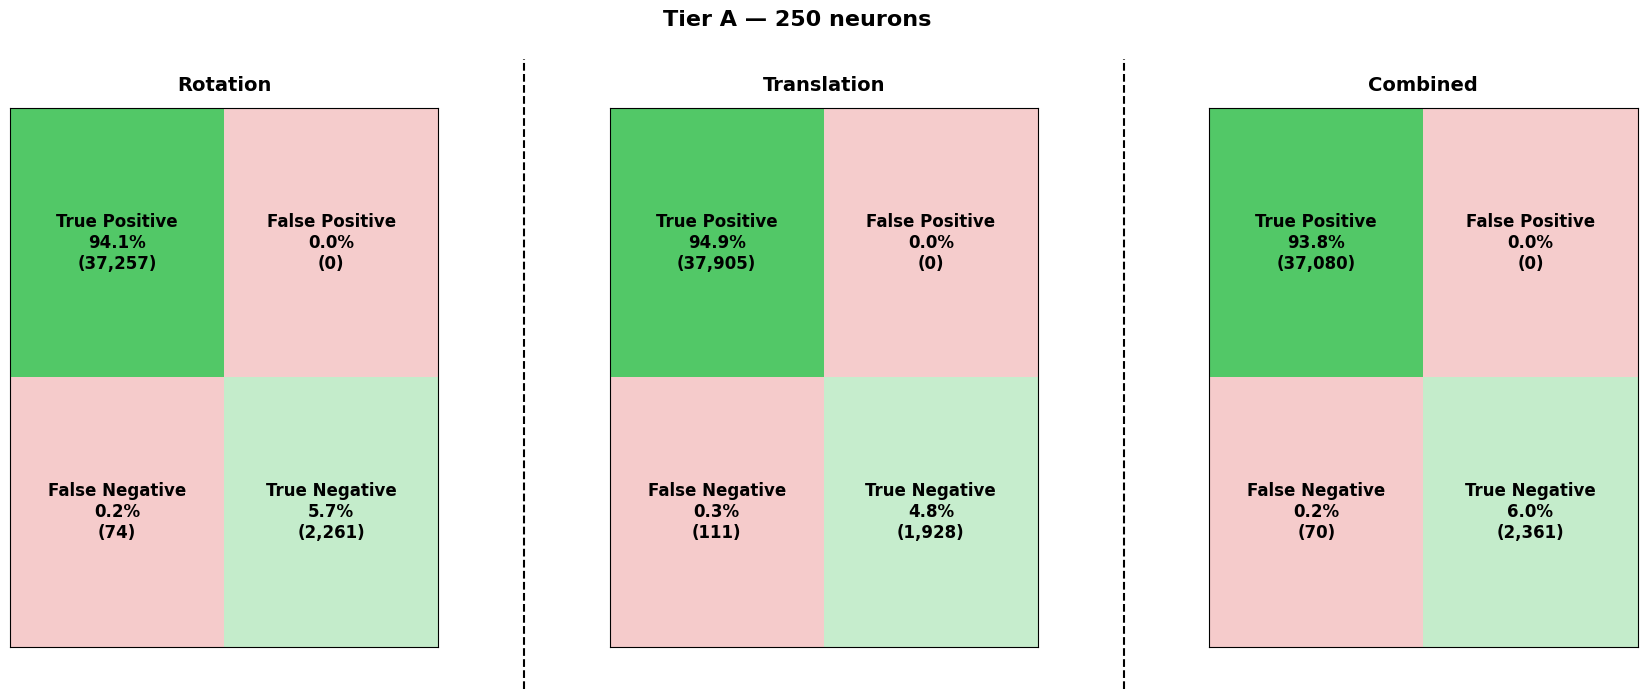

  Tier B -> C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_250n\confusion_tier_B.png


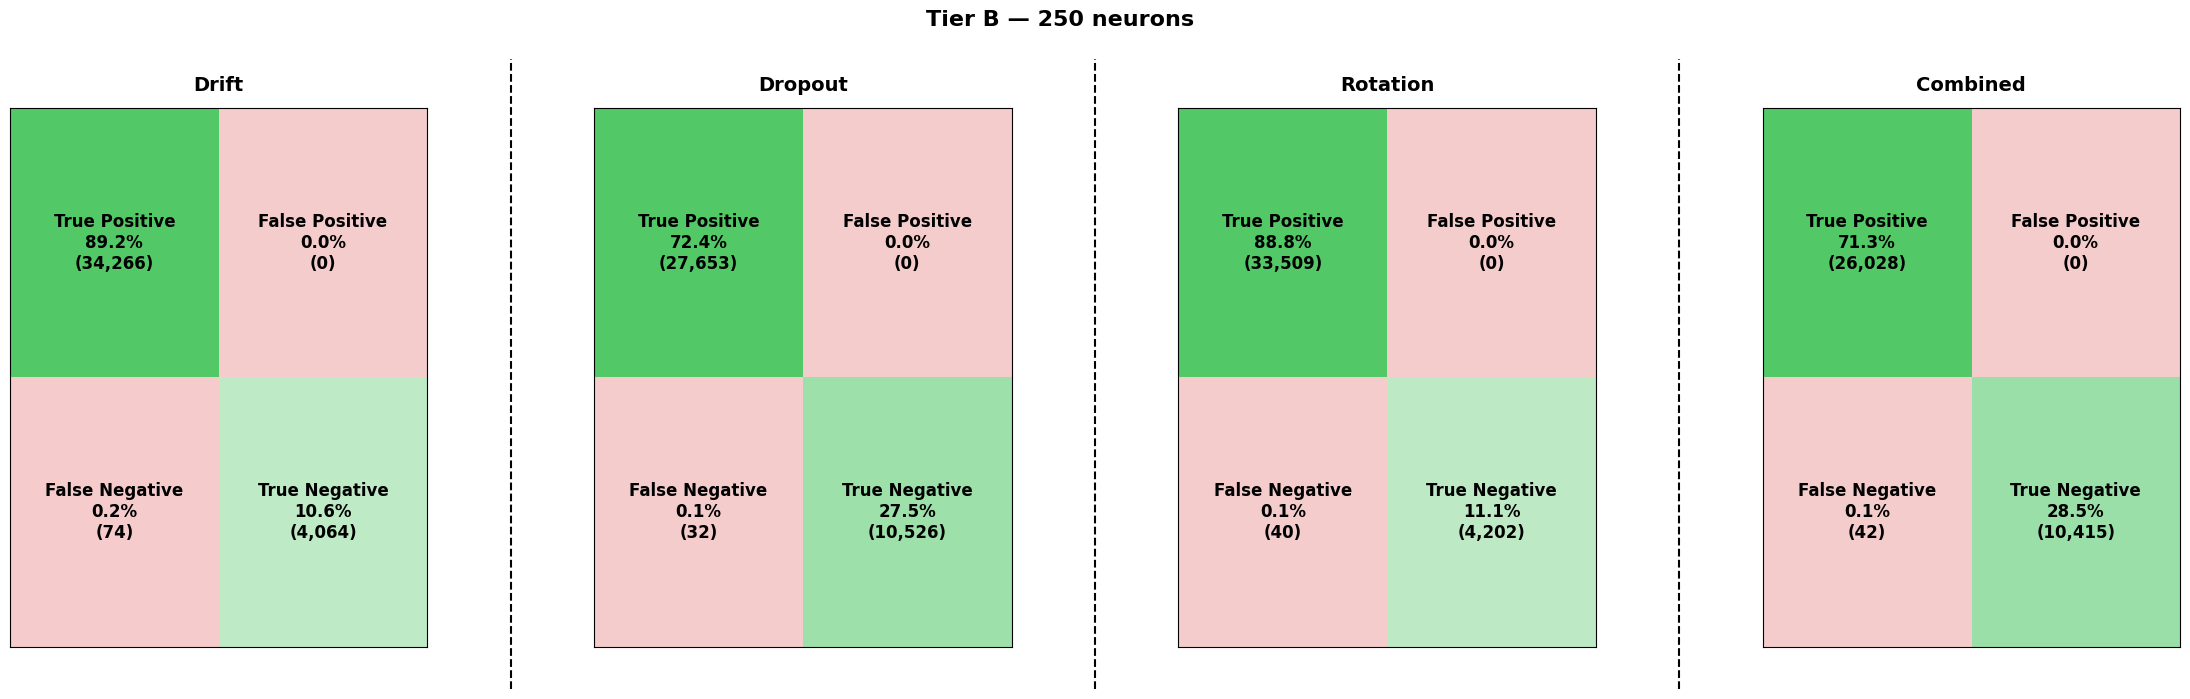

  Tier C -> C:\Users\ariAccount\Desktop\Stars2Cells_Benchmark_250n\confusion_tier_C.png


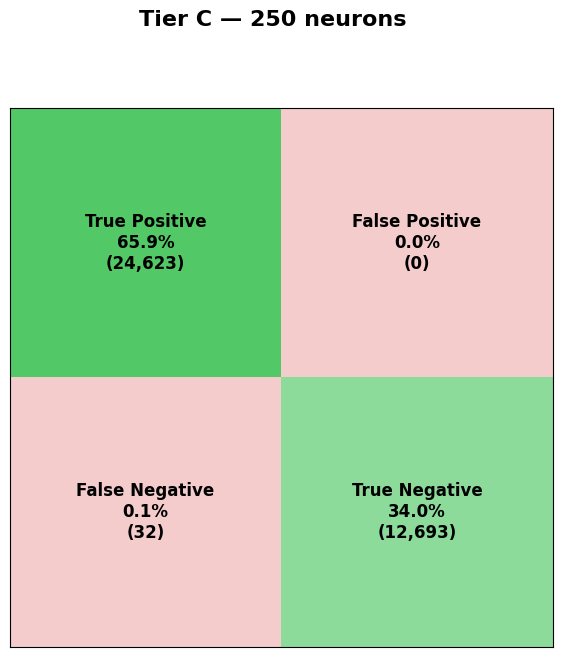


  DONE — 250n


In [14]:
# %%
"""
Ground Truth Inspector & Verifier for Stars2Cells Benchmark  (v5)
==================================================================
Callable function for any neuron count (100, 250, 500, 1000).
Simplified scoring: TP / FP / FN / TN (no avoidable/unavoidable split).
Gracefully skips tiers with no results.

Usage:
    run_benchmark(500)
    run_benchmark(100)
    run_benchmark(1000)
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path(r"C:\Users\ariAccount\Desktop")

TIER_MAP = {
    'T0_identity': '0',
    'A_rot': 'A', 'A_trans': 'A', 'A_combined': 'A',
    'B_dropout': 'B', 'B_drift': 'B', 'B_rot': 'B', 'B_combined': 'B',
    'C_walk': 'C',
}

COND_DISPLAY = {
    'T0_identity': 'Identity',
    'A_rot': 'Rotation', 'A_trans': 'Translation', 'A_combined': 'Combined',
    'B_rot': 'Rotation', 'B_drift': 'Drift', 'B_dropout': 'Dropout',
    'B_combined': 'Combined',
    'C_walk': None,
}


# ═══════════════════════════════════════════════════════════════════════════
# SCORING HELPER
# ═══════════════════════════════════════════════════════════════════════════
def score_pair(matched_ref, matched_tgt, ref_base_ids, tgt_base_ids):
    """
    Simple TP / FP / FN / TN scoring.

    TP:  matched pair has same base ID (and that ID is shared)
    FP:  matched pair has different base IDs
    FN:  shared neuron not correctly matched
    TN:  non-shared neuron not in any match
    """
    ref_id_set = set(ref_base_ids)
    tgt_id_set = set(tgt_base_ids)
    shared_ids = ref_id_set & tgt_id_set
    n_ref = len(ref_base_ids)
    n_tgt = len(tgt_base_ids)

    matched_ref_set = set(int(x) for x in matched_ref)
    matched_tgt_set = set(int(x) for x in matched_tgt)

    tp = 0
    fp = 0
    correctly_matched_ids = set()

    for ri, ti in zip(matched_ref, matched_tgt):
        ri, ti = int(ri), int(ti)
        if ri < n_ref and ti < n_tgt:
            r_id = ref_base_ids[ri]
            t_id = tgt_base_ids[ti]
            if r_id == t_id and r_id in shared_ids:
                tp += 1
                correctly_matched_ids.add(r_id)
            else:
                fp += 1
        else:
            fp += 1

    fn = len(shared_ids) - len(correctly_matched_ids)

    nonshared_ref = {i for i, bid in enumerate(ref_base_ids) if bid not in shared_ids}
    nonshared_tgt = {i for i, bid in enumerate(tgt_base_ids) if bid not in shared_ids}
    nonshared_in_match = set()
    for ri in (nonshared_ref & matched_ref_set):
        nonshared_in_match.add(('ref', ref_base_ids[ri]))
    for ti in (nonshared_tgt & matched_tgt_set):
        nonshared_in_match.add(('tgt', tgt_base_ids[ti]))
    n_nonshared = len(nonshared_ref) + len(nonshared_tgt)
    tn = n_nonshared - len(nonshared_in_match)

    n_matches = len(matched_ref)
    n_shared = len(shared_ids)

    def _safe_div(a, b):
        return a / b if b > 0 else float('nan')

    def _f1(p, r):
        if np.isnan(p) or np.isnan(r) or (p + r) == 0:
            return float('nan')
        return 2 * p * r / (p + r)

    prec = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)

    return {
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'n_shared': n_shared, 'n_nonshared': n_nonshared,
        'n_ref': n_ref, 'n_tgt': n_tgt, 'n_matches': n_matches,
        'precision': prec, 'recall': recall,
        'f1': _f1(prec, recall),
    }


# ═══════════════════════════════════════════════════════════════════════════
# MAIN FUNCTION
# ═══════════════════════════════════════════════════════════════════════════
def run_benchmark(n_neurons, base_dir=BASE_DIR, save_figures=True):
    """
    Run the full benchmark inspector for a given neuron count.

    Parameters
    ----------
    n_neurons : int
        One of 100, 250, 500, 1000 (or any folder named
        Stars2Cells_Benchmark_{n}n).
    base_dir : Path
        Parent directory containing the benchmark folders.
    save_figures : bool
        Whether to save confusion matrix PNGs.
    """
    data_dir = Path(base_dir) / f"Stars2Cells_Benchmark_{n_neurons}n"
    results_dir = data_dir / "step_3_results"

    print(f"\n{'█' * 70}")
    print(f"  STARS2CELLS BENCHMARK — {n_neurons} neurons")
    print(f"{'█' * 70}")
    print(f"  Data dir    : {data_dir}")
    print(f"  Results dir : {results_dir}")

    # ── Load ground truth ──
    gt_path = data_dir / "ground_truth.npy"
    if not gt_path.exists():
        print(f"\n  ERROR: Ground truth not found at {gt_path}")
        return None
    gt = np.load(gt_path, allow_pickle=True).item()
    print(f"  GT entries  : {len(gt)}")

    # ── Quick GT stats ──
    conditions_found = set()
    cond_counts = defaultdict(list)
    for fname, entry in gt.items():
        cond = fname.replace(".npy", "").split("__")[1]
        conditions_found.add(cond)
        cond_counts[cond].append(len(entry['ground_truth_base_ids']))

    print(f"  Conditions  : {sorted(conditions_found)}")
    print(f"\n  Neuron counts per condition:")
    for cond in sorted(cond_counts.keys()):
        c = cond_counts[cond]
        print(f"    {cond:15s} -- mean={np.mean(c):.1f}, min={np.min(c)}, max={np.max(c)}")

    # ── Find sweep files ──
    step3_dir = None
    for candidate in [results_dir / "step_3_results", results_dir / "step_3", results_dir]:
        if candidate.exists() and list(candidate.glob("*_sweep.npz")):
            step3_dir = candidate
            break

    sweep_files = sorted(step3_dir.glob("*_sweep.npz")) if step3_dir else []
    print(f"\n  Sweep files : {len(sweep_files)}")

    if not sweep_files:
        print("  No sweep files found — nothing to score.")
        return None

    # ── Score all pairs ──
    pair_scores = []
    key_errors = 0

    _empty = {
        'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0,
        'n_matches': 0, 'n_shared': 0, 'n_nonshared': 0,
        'n_ref': 0, 'n_tgt': 0,
        'precision': float('nan'), 'recall': float('nan'),
        'f1': float('nan'),
    }

    for sweep_file in sweep_files:
        data = np.load(sweep_file, allow_pickle=False)

        animal_id   = str(data['animal_id'])
        pair_name   = str(data['pair_name'])
        ref_session = str(data['ref_session'])
        tgt_session = str(data['target_session'])
        matched_ref = data['matched_ref_indices']
        matched_tgt = data['matched_tgt_indices']
        n_matches   = len(matched_ref)

        parts = ref_session.split("__")
        cond_found = parts[1] if len(parts) >= 2 else "?"
        seed_found = parts[2] if len(parts) >= 3 else "?"
        tier_found = TIER_MAP.get(cond_found, "?")

        base_info = {
            'pair_name': pair_name, 'animal_id': animal_id,
            'ref_session': ref_session, 'tgt_session': tgt_session,
            'condition': cond_found, 'seed': seed_found, 'tier': tier_found,
        }

        ref_gt_key = f"{ref_session}.npy"
        tgt_gt_key = f"{tgt_session}.npy"

        if n_matches == 0 or ref_gt_key not in gt or tgt_gt_key not in gt:
            if ref_gt_key not in gt or tgt_gt_key not in gt:
                key_errors += 1
            pair_scores.append({**base_info, **_empty, 'n_matches': n_matches})
            continue

        ref_base_ids = gt[ref_gt_key]['ground_truth_base_ids']
        tgt_base_ids = gt[tgt_gt_key]['ground_truth_base_ids']
        result = score_pair(matched_ref, matched_tgt, ref_base_ids, tgt_base_ids)
        pair_scores.append({**base_info, **result})

    # ── Summary table ──
    print(f"\n{'=' * 70}")
    print(f"  RESULTS  ({len(pair_scores)} pairs scored, {key_errors} key errors)")
    print(f"{'=' * 70}\n")

    print(f"  {'Pair':<55} {'Cond':<12} {'Shrd':>4} {'TP':>5} {'FP':>5} "
          f"{'FN':>5} {'TN':>5} {'Prec':>6} {'Rec':>6} {'F1':>6}")
    print(f"  {'─' * 120}")
    for ps in sorted(pair_scores, key=lambda x: (x['tier'], x['condition'], x['pair_name'])):
        p_s = f"{ps['precision']*100:.0f}%" if not np.isnan(ps['precision']) else "N/A"
        r_s = f"{ps['recall']*100:.0f}%" if not np.isnan(ps['recall']) else "N/A"
        f_s = f"{ps['f1']*100:.0f}%" if not np.isnan(ps['f1']) else "N/A"
        print(f"  {ps['pair_name']:<55} {ps['condition']:<12} "
              f"{ps['n_shared']:>4} {ps['tp']:>5} {ps['fp']:>5} "
              f"{ps['fn']:>5} {ps['tn']:>5} {p_s:>6} {r_s:>6} {f_s:>6}")

    # ── Per-condition summary ──
    print(f"\n  {'─' * 80}")
    print(f"  SUMMARY BY CONDITION:")
    print(f"  {'─' * 80}")
    print(f"  {'Condition':<15} {'Tier':>4} {'n':>5} {'Prec':>8} {'Recall':>8} {'F1':>8}")
    print(f"  {'─' * 80}")

    cond_m = defaultdict(lambda: {'p': [], 'r': [], 'f1': []})
    for ps in pair_scores:
        c = ps['condition']
        if not np.isnan(ps['precision']):
            cond_m[c]['p'].append(ps['precision'])
        if not np.isnan(ps['recall']):
            cond_m[c]['r'].append(ps['recall'])
        if not np.isnan(ps['f1']):
            cond_m[c]['f1'].append(ps['f1'])

    for cond in sorted(cond_m.keys()):
        m = cond_m[cond]
        tier = TIER_MAP.get(cond, '?')
        n = max(len(m['p']), len(m['r']), len(m['f1']))
        p_avg = np.mean(m['p']) * 100 if m['p'] else float('nan')
        r_avg = np.mean(m['r']) * 100 if m['r'] else float('nan')
        f_avg = np.mean(m['f1']) * 100 if m['f1'] else float('nan')
        print(f"  {cond:<15} {tier:>4} {n:>5} {p_avg:>7.1f}% {r_avg:>7.1f}% {f_avg:>7.1f}%")

    def _safe_mean(key):
        vals = [ps[key] for ps in pair_scores if not np.isnan(ps[key])]
        return np.mean(vals) * 100 if vals else float('nan')

    print(f"\n  OVERALL:")
    print(f"    Precision:  {_safe_mean('precision'):.1f}%")
    print(f"    Recall:     {_safe_mean('recall'):.1f}%")
    print(f"    F1:         {_safe_mean('f1'):.1f}%")

    # ── 2×2 Confusion matrices per tier ──
    print(f"\n{'=' * 70}")
    print("  CONFUSION MATRICES (one per tier)")
    print(f"{'=' * 70}")

    for tier_label in ['0', 'A', 'B', 'C']:
        tier_pairs = [ps for ps in pair_scores
                      if ps['tier'] == tier_label
                      and not np.isnan(ps['recall'])]
        if not tier_pairs:
            continue

        cond_totals = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0})
        for ps in tier_pairs:
            c = ps['condition']
            cond_totals[c]['tp'] += ps['tp']
            cond_totals[c]['fp'] += ps['fp']
            cond_totals[c]['fn'] += ps['fn']
            cond_totals[c]['tn'] += ps['tn']

        cond_names = sorted(cond_totals.keys(),
                            key=lambda c: (1 if 'combined' in c.lower() else 0, c))
        n_conds = len(cond_names)

        fig, axes = plt.subplots(1, n_conds,
                                  figsize=(7 * n_conds, 7),
                                  gridspec_kw={'wspace': 0.4})
        if n_conds == 1:
            axes = [axes]

        for col, cname in enumerate(cond_names):
            ax = axes[col]
            t = cond_totals[cname]

            mat = np.array([
                [t['tp'], t['fp']],
                [t['fn'], t['tn']],
            ], dtype=float)

            total = mat.sum()
            mat_pct = mat / total * 100 if total > 0 else mat * 0

            colors = np.zeros((2, 2, 4))
            color_map = {
                (0, 0): [0.2, 0.75, 0.3],
                (0, 1): [0.85, 0.2, 0.2],
                (1, 0): [0.85, 0.2, 0.2],
                (1, 1): [0.2, 0.75, 0.3],
            }
            max_pct = mat_pct.max() if mat_pct.max() > 0 else 1
            for r in range(2):
                for c_idx in range(2):
                    colors[r, c_idx, :3] = color_map[(r, c_idx)]
                    colors[r, c_idx, 3] = 0.25 + 0.6 * (mat_pct[r, c_idx] / max_pct)

            ax.imshow(colors, aspect='auto', interpolation='none')

            labels_2x2 = [['True Positive', 'False Positive'],
                          ['False Negative', 'True Negative']]
            for r in range(2):
                for c_idx in range(2):
                    pct = mat_pct[r, c_idx]
                    count = int(mat[r, c_idx])
                    ax.text(c_idx, r,
                            f"{labels_2x2[r][c_idx]}\n{pct:.1f}%\n({count:,})",
                            ha='center', va='center',
                            fontsize=12, fontweight='bold', color='black')

            ax.set_xticks([])
            ax.set_yticks([])

            display_name = COND_DISPLAY.get(cname, cname)
            if display_name:
                ax.set_title(display_name, fontsize=14, fontweight='bold', pad=12)

        if n_conds > 1:
            for col in range(n_conds - 1):
                bbox_right = axes[col].get_position()
                bbox_left  = axes[col + 1].get_position()
                mid_x = (bbox_right.x1 + bbox_left.x0) / 2
                fig.add_artist(plt.Line2D(
                    [mid_x, mid_x], [0.05, 0.95],
                    transform=fig.transFigure,
                    color='black', linestyle='--', linewidth=1.5,
                ))

        tier_display = '0 (Identity)' if tier_label == '0' else tier_label
        fig.suptitle(f"Tier {tier_display} — {n_neurons} neurons",
                     fontsize=16, fontweight='bold', y=1.02)

        if save_figures:
            save_path = data_dir / f"confusion_tier_{tier_label}.png"
            fig.tight_layout()
            if n_conds > 1:
                fig.artists.clear()
                for col in range(n_conds - 1):
                    bbox_right = axes[col].get_position()
                    bbox_left  = axes[col + 1].get_position()
                    mid_x = (bbox_right.x1 + bbox_left.x0) / 2
                    fig.add_artist(plt.Line2D(
                        [mid_x, mid_x], [0.05, 0.95],
                        transform=fig.transFigure,
                        color='black', linestyle='--', linewidth=1.5,
                    ))
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Tier {tier_display} -> {save_path}")

        plt.show()

    print(f"\n{'=' * 70}")
    print(f"  DONE — {n_neurons}n")
    print(f"{'=' * 70}")

    return pair_scores


# ═══════════════════════════════════════════════════════════════════════════
# RUN
# ═══════════════════════════════════════════════════════════════════════════

# %%
# results_100 = run_benchmark(100)

# %%
results_250 = run_benchmark(250)

# %%
# results_500 = run_benchmark(500)

# %%
# results_1000 = run_benchmark(1000)